# Show2D

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/bobleesj/quantem.widget/blob/main/docs/tutorials/show2d.ipynb)

`Show2D` renders one or many 2D images with contrast control, an FFT toggle, ROIs, line profiles, and a calibrated scale bar. It accepts a NumPy array, a PyTorch tensor, or a quantem `Dataset2d`.

This tutorial uses a real gold HAADF image from the public [`bobleesj/quantem-data`](https://huggingface.co/datasets/bobleesj/quantem-data) Hugging Face dataset. The full image is 4096 by 4096 pixels; the viewer below uses a calibrated preview so the notebook starts quickly in the documentation site and in Colab.

```{tip}
Run this exact notebook with the Colab badge above, or [View or download this notebook on GitHub](https://github.com/bobleesj/quantem.widget/blob/main/docs/tutorials/show2d.ipynb). For finished results, use [Saving and sharing](widget_export) to export interactive HTML or share a trusted notebook with widget state.
```


In [1]:
import subprocess
import sys

try:
    import google.colab  # noqa: F401
except Exception:
    pass
else:
    from google.colab import output

    output.enable_custom_widget_manager()
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/bobleesj/quantem.widget.git"],
        check=True,
    )

import numpy as np
from quantem.core.datastructures import Dataset2d
from quantem.widget import Show2D
from quantem.widget.data import load_tutorial_show2d

dataset2d = load_tutorial_show2d(stride=8)
image = dataset2d.array


Source: gold_haadf_npy from Hugging Face
Full image: 4096 x 4096 uint16
Preview: 512 x 512, pixel size 0.1489 nm


## Single image

The HAADF image is wrapped in a quantem `Dataset2d`, so the calibration travels with the array. The widget reads that metadata automatically and draws a physical scale bar without a widget-level pixel-size argument.

Show2D(512×512, cmap=inferno)

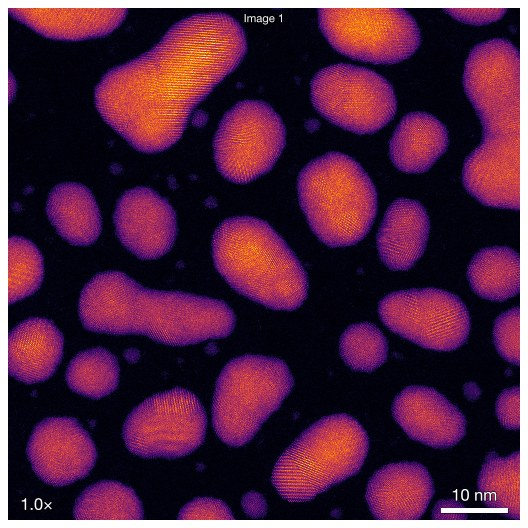

In [2]:
Show2D(dataset2d, offline=True, cmap="inferno")

## A gallery of related views

Pass a list of calibrated `Dataset2d` objects to compare related real-data views side by side. The contrast and zoom controls can be linked across panels.

Show2D(3×512×512, idx=0, cmap=inferno)

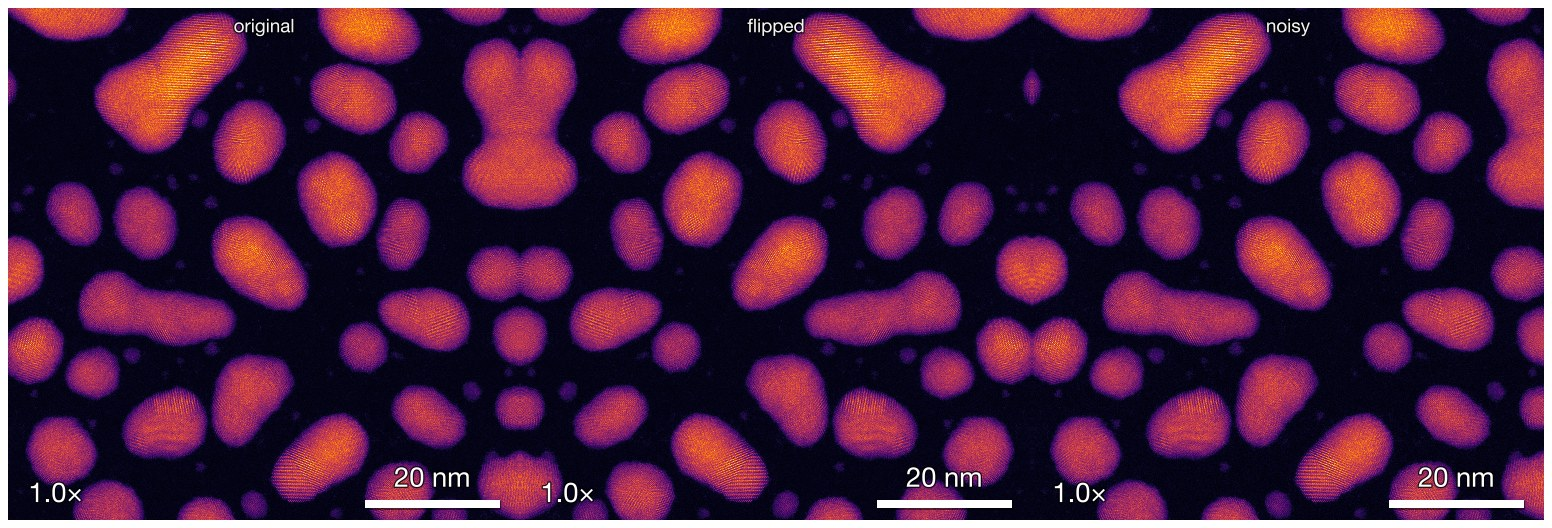

In [3]:
rng = np.random.default_rng(0)
noise = 0.03 * float(np.std(image)) * rng.standard_normal(image.shape).astype(np.float32)
variant_arrays = [image, np.fliplr(image), image + noise]
variant_names = ["original", "flipped", "noisy"]
variant_datasets = [
    Dataset2d.from_array(arr, sampling=dataset2d.sampling, units=dataset2d.units, name=name)
    for arr, name in zip(variant_arrays, variant_names)
]

Show2D(variant_datasets, labels=variant_names, offline=True)

## Trigger a fresh render in an existing widget

When a notebook loop produces a new image, keep the same widget object and call `set_image()`. That method is the render trigger: it sends fresh synced image bytes to the browser and resets stale panel-specific state. Mutating the original NumPy array in place is not enough because the frontend only repaints when a synced trait changes.

Use `offline=False` for acquisition-style updates so each replacement travels through the live Jupyter Comm path instead of the saved/offline notebook representation.


In [ ]:
live2d = Show2D(dataset2d, labels=["original"], offline=False, cmap="inferno")
live2d


In [ ]:
updated_gallery = np.stack([
    image,
    np.flipud(image),
    np.clip(image * 0.85 + 0.15 * float(image.mean()), 0, None),
])

live2d.set_image(
    updated_gallery,
    labels=["original", "flipped up/down", "contrast adjusted"],
)
